In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


Load ERA5/Obs data

In [2]:
def df_xr_prep(df):
    da=df.to_xarray()
    da=da.rename({'index':'year'})
    return da

##La Plata
#SON
era_SON_LaPlata_df=pd.read_csv('../data_ready/7_with_VB.csv',index_col='Unnamed: 0')

#era_SON_LaPlata_df=era_SON_LaPlata_df.rename(index_col='year')
era_SON_LaPlata_array=era_SON_LaPlata_df.to_xarray()
era_SON_LaPlata_array=era_SON_LaPlata_array.rename({'index':'year'})

#DJF
era_DJF_LaPlata_df=pd.read_csv('../data_ready/6_with_IOBW_VB.csv', index_col='Unnamed: 0')
era_DJF_LaPlata_array=df_xr_prep(era_DJF_LaPlata_df)

##Andes
#SON
era_SON_Andes_df=pd.read_csv('../data_ready/5_with_VB.csv',index_col='Unnamed: 0')
era_SON_Andes_array=df_xr_prep(era_SON_Andes_df)

#DJF
era_DJF_Andes_df=pd.read_csv('../data_ready/4_with_IOBW_VB.csv', index_col='Unnamed: 0')
era_DJF_Andes_array=df_xr_prep(era_DJF_Andes_df)
display(era_DJF_Andes_array)

<xarray.Dataset> Size: 8kB
Dimensions:        (year: 73)
Coordinates:
  * year           (year) int64 584B 1951 1952 1953 1954 ... 2022 2023 2024 1950
Data variables: (12/13)
    t_Andes        (year) float64 584B -1.791 0.5614 -0.2617 ... 0.6017 nan
    precip_Andes   (year) float64 584B 0.129 0.4549 -1.375 ... -0.2223 -1.51 nan
    ENSO           (year) float64 584B -0.6866 0.5838 0.3068 ... 1.632 nan
    IOD            (year) float64 584B 0.2555 0.6281 1.26 ... 0.9651 4.209 nan
    EDJ            (year) float64 584B 1.783 0.6677 -0.5056 ... 0.1875 nan
    EDJ_lat        (year) float64 584B -0.6985 1.359 -0.9556 ... -2.241 nan
    ...             ...
    SPV            (year) float64 584B 0.2633 -0.6312 1.451 ... 1.702 1.85 nan
    A_SAM          (year) float64 584B 0.233 -1.135 -2.197 ... 1.774 0.05365 nan
    S_SAM          (year) float64 584B 0.6038 -1.058 0.1437 ... 1.93 1.88 nan
    IOBW           (year) float64 584B -1.546 0.8591 -0.3374 ... 2.389 nan
    VB             (year) float64 584B -0.0653 -0.101 0.2247 ... 0.7241 nan
    VB_class       (year) object 584B 'Early' 'Early' 'Late' ... 'Late' 'Early'

Load Hindcast data

In [90]:
path='/climca/people/glattus/Hindcast_data_ready/'
ds_Andes_SON=xr.open_dataset(path+'Target_vars_Andes_SON.nc')
ds_Andes_DJF=xr.open_dataset(path+'Target_vars_Andes_DJF.nc')
display(ds_Andes_SON)

<xarray.Dataset> Size: 317kB
Dimensions:                  (sample: 2142)
Coordinates:
    lead_block               (sample) <U10 86kB ...
    forecast_reference_time  (sample) datetime64[ns] 17kB ...
    number                   (sample) int64 17kB ...
    real_season              (sample) <U3 26kB ...
    real_months              (sample) <U8 69kB ...
    season_label             (sample) <U8 69kB ...
Dimensions without coordinates: sample
Data variables:
    t2m                      (sample) float64 17kB ...
    tp                       (sample) float64 17kB ...

Bootstrap hindcast data from the different ensembles

In [17]:
len_boot=len(era_DJF_Andes_array.year)
print(len_boot)

73


In [95]:
def generate_samples(ds, len_boot=len_boot):
    'This selects one random ensemble member (can also be the same) from each year'
    'and fills up the missing years to have sample size as era5 data with random years and random members'
    years = np.unique(ds.forecast_reference_time.values)
    members = ds.number.values
    samples=[]
    # Step 1: one random member from each year
    for year in years:
        member = np.random.choice(members)

        value = ds.where(
            (ds['forecast_reference_time']==year) &
            (ds['number']==member), drop=True
        ).values

        samples.append(value)

    # Step 2: fill remaining slots
    remaining = len_boot - len(samples)

    for _ in range(remaining):

        year = np.random.choice(years)
        member = np.random.choice(members)

        value = ds.where(
            (ds['forecast_reference_time']==year) &
            (ds['number']==member), drop=True
        ).values

        samples.append(value)

    return np.array(samples)

def bootstrap_chain(ds, iterations):
    bootstrap_samples=[]
    seed=np.random.seed(42)
    for i in range(iterations):
        bootstrap_samples.append(generate_samples(ds))

    return np.array(bootstrap_samples)

def model_eval_plot(boot_samples, era5_array, input_title):
    #1. compute percentiles (1% to 100%), ignore NaNs!
    boot_percentiles = np.nanpercentile(boot_samples, np.arange(0,100,1), axis=1)
    era5_percentiles=np.nanpercentile(era5_array, np.arange(0,100,1))
    #2. compute bootstrap mean and std (because many different bootstrap samples generated)
    boot_perc_mean=np.mean(boot_percentiles, axis=1).squeeze()
    boot_perc_std=np.std(boot_percentiles, axis=1).squeeze()
    #print(np.shape(boot_perc_mean), np.shape(boot_perc_std))

    #3. plot scatter plot
    plt.plot(era5_percentiles, era5_percentiles, label='1:1 line', color='black')
    plt.scatter(era5_percentiles, boot_perc_mean, marker='o', color='blue', label='Mean of all Bootstrap samples')
    plt.fill_between(era5_percentiles, y1=boot_perc_mean-boot_perc_std, y2=boot_perc_mean+boot_perc_std,
                     alpha=.5, label='1x$\sigma$ interval')
    plt.xlabel('ERA5 (observed) Data')
    plt.ylabel('Hindcast (modelled) Data')
    plt.title(input_title)
    plt.legend()
    plt.grid(alpha=.3)
    plt.show()
    return boot_percentiles, era5_percentiles



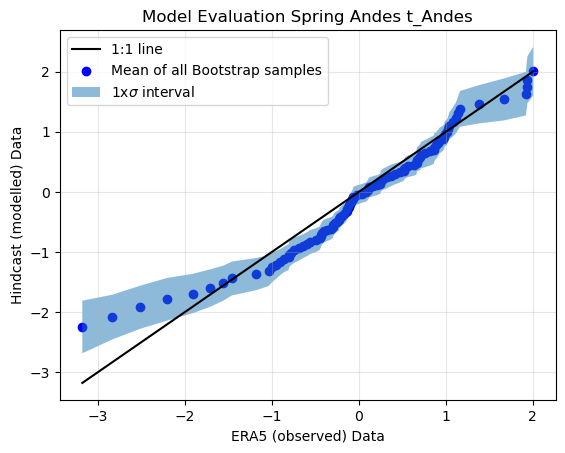

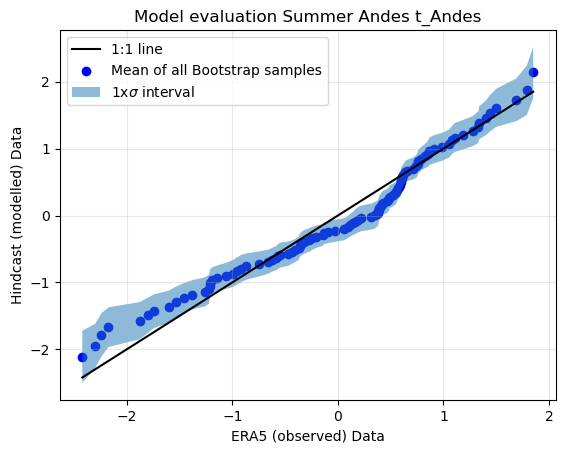

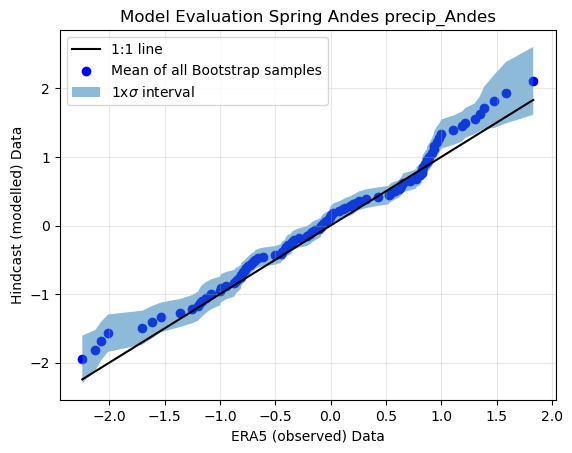

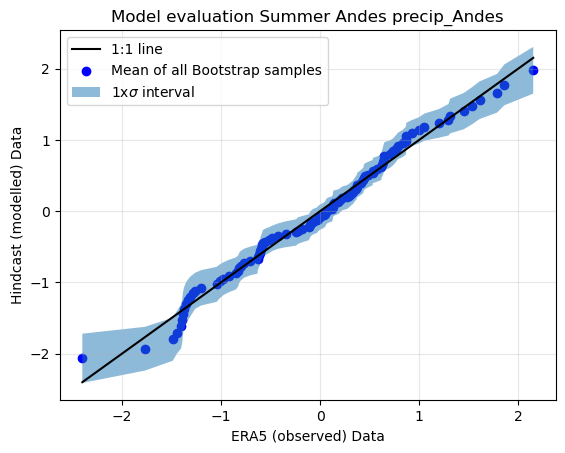

In [96]:
var_era5=['t_Andes', 'precip_Andes']
for i, var in enumerate(ds_Andes_SON.data_vars):
    a=bootstrap_chain(ds_Andes_SON[var], 50)
    boot_perc_Andes_SON, era5_perc_Andes_SON=model_eval_plot(a, era5_array=era_SON_Andes_array[var_era5[i]],
                                                input_title=f'Model Evaluation Spring Andes {var_era5[i]}')
    b=bootstrap_chain(ds_Andes_DJF[var], 50)
    boot_perc_Andes_DJF, era5_perc_Andes_DJF=model_eval_plot(b,
                                                             era_DJF_Andes_array[var_era5[i]],
                                                             input_title=f'Model evaluation Summer Andes {var_era5[i]}')